In [ ]:
#pip install mlxtend

  Using cached mlxtend-0.23.4-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.23.4-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier
from mlxtend.plotting import plot_decision_regions
import random
from sklearn.preprocessing import StandardScaler

In [37]:
# Generate dataset ---
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=2, n_classes=3, n_clusters_per_class=1, 
                           n_redundant=0, n_informative=2, class_sep=4.0, random_state=42)

y

array([2, 2, 2, 1, 2, 2, 1, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 0, 0,
       2, 1, 2, 0, 2, 1, 2, 1, 0, 1, 2, 1, 0, 0, 2, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       1, 1, 1, 2, 2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 2, 1, 0, 0, 1, 2, 2,
       2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 1, 0, 0, 1, 1, 2, 1, 2, 2, 2,
       0, 2, 2, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 0, 0, 1, 2, 2, 1, 0, 1,
       0, 0, 2, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 2, 0, 2, 0, 1, 1, 0,
       0, 1, 2, 2, 0, 0, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1, 0,
       2, 1, 1, 2, 1, 1, 2, 1, 2, 0, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2,
       2, 2, 0, 1, 2, 0, 0, 2, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1,
       2, 2, 1, 2, 0, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 1, 0, 1, 0, 0, 1, 2,
       2, 1, 2, 1, 0, 0, 2, 0, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 0, 1,
       0, 1, 0, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,

In [38]:
# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [40]:
# Initialize SGDClassifier
model = SGDClassifier(loss='log_loss',        # Cross-entropy loss
                      learning_rate='constant', 
                      eta0=0.01,         # Step size
                      max_iter=1,        # One iteration per sample
                      tol=None,          # No early stopping
                      random_state=42)

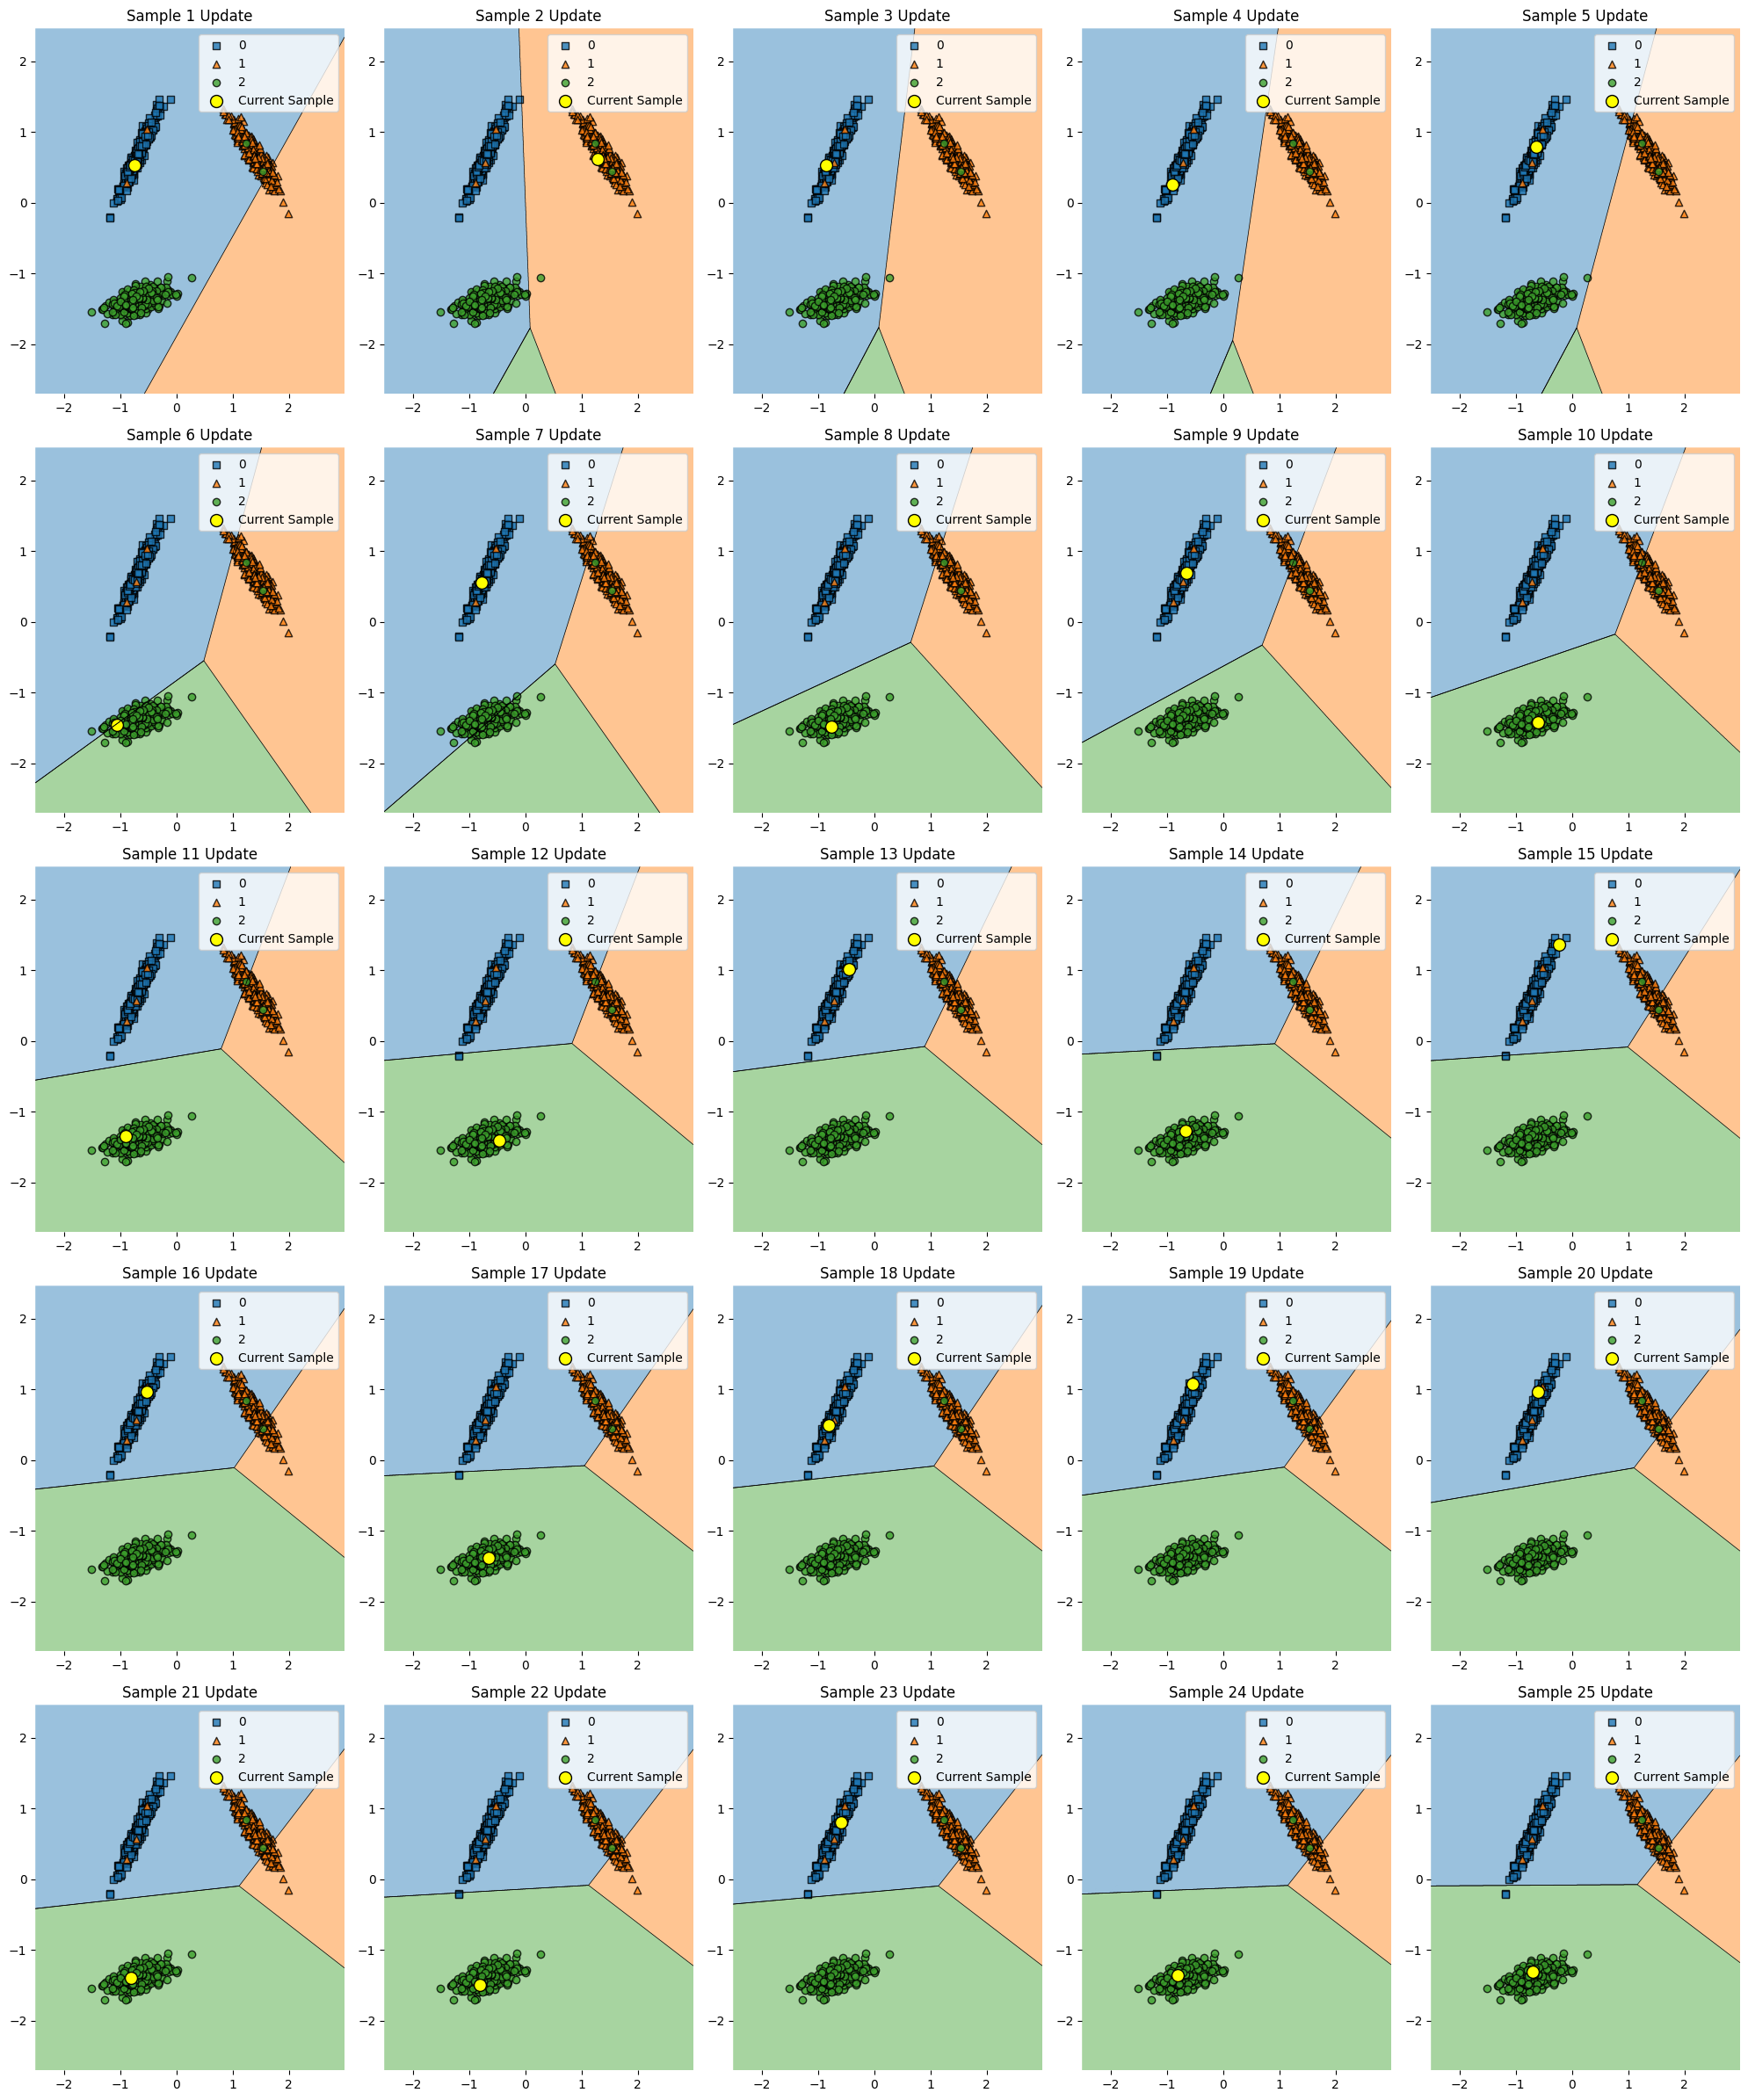

In [41]:
# Visualize 15 sample updates ---
fig, axes = plt.subplots(5, 5, figsize=(20, 24))

axes = axes.ravel()

classes = np.unique(y)   # [0, 1, 2]
first_fit = True

for i in range(25):
    # --- Select a random sample ---
    idx = random.randint(0, len(X) - 1)
    X_sample = X[idx].reshape(1, -1) #Picks the row
    y_sample = np.array([y[idx]])  #Pick the column

    # --- Update the model with a single sample ---
    #model.partial_fit(X_sample, y_sample, classes=[0, 1, 2])
    if first_fit:
        model.partial_fit(X_sample, y_sample, classes=classes)
        first_fit = False
    else:
        model.partial_fit(X_sample, y_sample)

    # --- Plot decision boundary ---
    ax = axes[i]
    plot_decision_regions(X, y, clf=model, ax=ax)
    
    ax.scatter(X_sample[:, 0], X_sample[:, 1], c='yellow', edgecolor='k', s=100, label='Current Sample')
    ax.set_title(f"Sample {i + 1} Update")
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Batch GD, SGD, and Mini-batch GD: Concepts, Use Cases, and Importance for GenAI Developers

#### 1. Batch Gradient Descent (GD)
- **How it works:** Uses the entire dataset to compute the gradient and update model parameters once per epoch.
- **Pros:** Stable convergence, smooth loss curve.
- **Cons:** Slow for large datasets, high memory usage.
- **Use cases:**
  - Small to medium datasets where memory is not a constraint.
  - When you want stable and accurate convergence.

#### 2. Stochastic Gradient Descent (SGD)
- **How it works:** Updates model parameters for each training sample (one at a time).
- **Pros:** Fast updates, can escape local minima, suitable for online learning.
- **Cons:** Noisy updates, may not converge smoothly.
- **Use cases:**
  - Very large or streaming datasets.
  - When quick, incremental updates are needed (e.g., online learning, real-time systems).

#### 3. Mini-batch Gradient Descent
- **How it works:** Updates model parameters using small random subsets (mini-batches) of the data.
- **Pros:** Balance between speed and stability, efficient with vectorized operations, widely used in deep learning.
- **Cons:** Requires tuning of batch size.
- **Use cases:**
  - Standard for training deep neural networks.
  - When you want to leverage hardware acceleration (GPUs/TPUs).
  - Large datasets where full batch is not feasible.


#### Why Should GenAI Developers Know About Types of GD?
- **Model Training Efficiency:** Choosing the right GD type impacts training speed, memory usage, and convergence quality.
- **Scalability:** GenAI models (like LLMs, diffusion models) are trained on massive datasets; mini-batch GD is essential for scalability.
- **Customization:** Understanding GD types allows developers to optimize training for specific hardware, data size, and application needs.
- **Real-world Deployment:** Online/continual learning (SGD) is crucial for adaptive GenAI systems that learn from new data in production.
- **Debugging and Optimization:** Knowledge of GD types helps in diagnosing training issues (e.g., slow convergence, overfitting) and improving model performance.



In [9]:
# Batch Gradient Descent (GD) with SGDClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

In [ ]:
# Generate a 2D, well-separated dataset for visualization
X, y = make_classification(
    n_samples       =1000,
    n_features      =2,
    n_informative   =2,
    n_redundant     =0,
    n_clusters_per_class=1,
    n_classes       =2,
    class_sep       =2.0,
    #random_state   =42
)

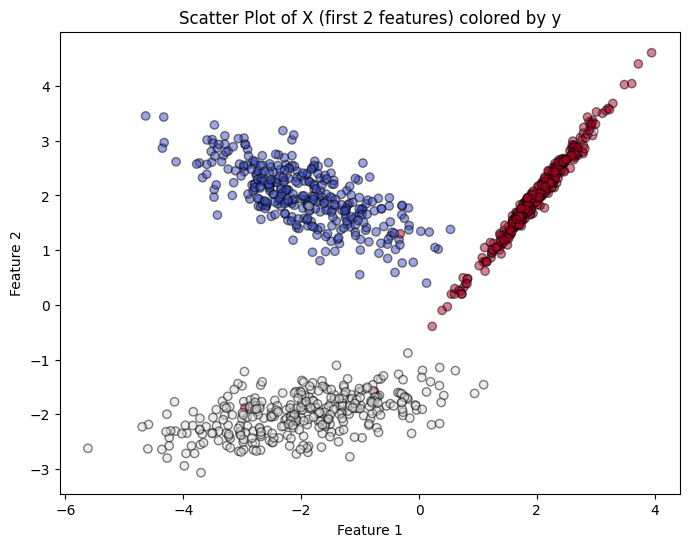

In [12]:
# Visualize the generated dataset (first two features)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.5, edgecolor='k')
plt.title('Scatter Plot of X (first 2 features) colored by y')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [21]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

- SGDClassifier is a linear model for classification that uses stochastic gradient descent to optimize its weights.
- It can implement different algorithms (perceptron, logistic regression, linear SVM) depending on the loss parameter.
- The model consists of a weight vector and a bias term, which define a linear decision boundary in the feature space.
- During training, it updates the weights incrementally using small batches or single samples.

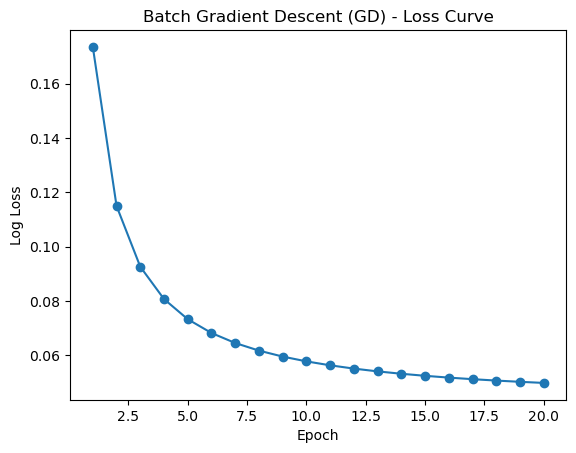

In [22]:
# Batch GD: fit on the whole dataset each epoch
model_batch = SGDClassifier(loss            = 'log_loss', 
                            learning_rate   = 'constant', 
                            eta0            = 0.01, 
                            max_iter        = 1, 
                            tol             = None, 
                            random_state    = 42, 
                            shuffle         = False)
losses_batch = []
num_epochs   = 20

for epoch in range(num_epochs):
    
    model_batch.partial_fit(X, y, classes=np.unique(y))
    
    y_pred_proba    = model_batch.predict_proba(X)
    loss            = log_loss(y, y_pred_proba)
    
    losses_batch.append(loss)

plt.plot(range(1, num_epochs+1), losses_batch, marker='o')
plt.title('Batch Gradient Descent (GD) - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.show()

#### How Batch Gradient Descent (GD) Training Works

- **Batch GD** computes the gradient of the loss function using the entire training dataset for each update.
- In each epoch, the model sees all samples, calculates the average gradient, and updates the weights once.
- This process is repeated for several epochs until the loss converges or a stopping criterion is met.
- **Advantages:** Stable and smooth convergence, especially for convex problems.
- **Disadvantages:** Can be slow and memory-intensive for large datasets, since all data must be loaded and processed together.

**In the code above:**
- The `partial_fit` method is called with the entire dataset `X, y` in each epoch.
- The loss is computed after each epoch and stored for visualization.
- The loss curve shows how the model improves as it sees the whole dataset repeatedly.

**Summary:**
- Batch GD is best for small to medium datasets where stability is more important than speed.

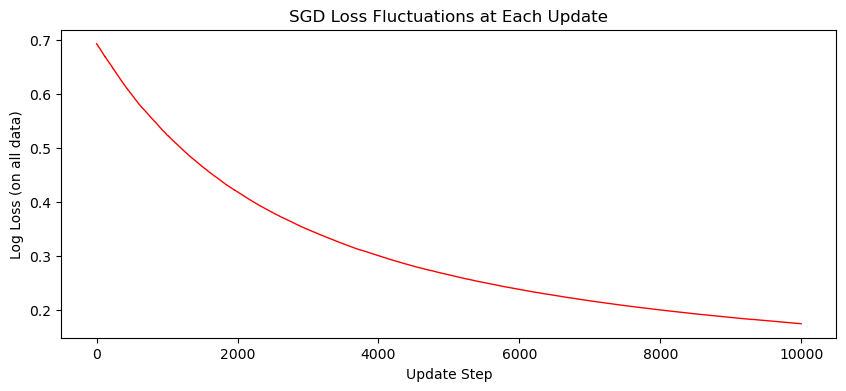

In [23]:
# Plot SGD loss at each update to show fluctuations
model_sgd2 = SGDClassifier(loss='log_loss', 
                           learning_rate='constant', 
                           eta0=0.001, 
                           max_iter=1, 
                           tol=None, 
                           random_state=42, 
                           shuffle=False)
losses_sgd_updates = []

n_samples  = X.shape[0]
num_epochs = 10  # Use fewer epochs for clarity

for epoch in range(num_epochs):
    
    indices = np.random.permutation(n_samples)
    
    for i, idx in enumerate(indices):
        
        X_sample = X[idx].reshape(1, -1)
        y_sample = np.array([y[idx]])
        
        model_sgd2.partial_fit(X_sample, y_sample, classes=np.unique(y))
        
        # Compute loss after each update
        y_pred_proba = model_sgd2.predict_proba(X)
        loss = log_loss(y, y_pred_proba)
        losses_sgd_updates.append(loss)

plt.figure(figsize=(10, 4))
plt.plot(losses_sgd_updates, color='red', linewidth=1)
plt.title('SGD Loss Fluctuations at Each Update')
plt.xlabel('Update Step')
plt.ylabel('Log Loss (on all data)')
plt.show()